In [1]:
pip install ultralytics wandb albumentations opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 52.2 MB/s eta 0:00:00


In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [9]:
!ls /content/drive/MyDrive/drone_detection


dataset  dataset-dronevsbird.zip


In [10]:
!ls /content/drive/MyDrive/drone_detection/dataset


bird  drone


In [14]:
!unzip /content/drive/MyDrive/drone_detection/dataset-dronevsbird.zip -d /content/drive/MyDrive/drone_detection/


Archive:  /content/drive/MyDrive/drone_detection/dataset-dronevsbird.zip
  inflating: /content/drive/MyDrive/drone_detection/dataset/bird/100.jpg  
  inflating: /content/drive/MyDrive/drone_detection/dataset/bird/101.jpg  
  inflating: /content/drive/MyDrive/drone_detection/dataset/bird/102.jpg  
  inflating: /content/drive/MyDrive/drone_detection/dataset/bird/103.jpg  
  inflating: /content/drive/MyDrive/drone_detection/dataset/bird/104.jpg  
  inflating: /content/drive/MyDrive/drone_detection/dataset/bird/105.jpg  
  inflating: /content/drive/MyDrive/drone_detection/dataset/bird/107.jpg  
  inflating: /content/drive/MyDrive/drone_detection/dataset/bird/109.jpg  
  inflating: /content/drive/MyDrive/drone_detection/dataset/bird/110.jpg  
  inflating: /content/drive/MyDrive/drone_detection/dataset/bird/111.jpg  
  inflating: /content/drive/MyDrive/drone_detection/dataset/bird/112.jpg  
  inflating: /content/drive/MyDrive/drone_detection/dataset/bird/113.jpg  
  inflating: /content/drive

In [15]:
!ls /content/drive/MyDrive/drone_detection/dataset


bird  drone


In [16]:
!ls /content/drive/MyDrive/drone_detection/dataset/bird | wc -l
!ls /content/drive/MyDrive/drone_detection/dataset/drone | wc -l


1607
2499


In [17]:
import os, shutil, random

SRC = "/content/drive/MyDrive/drone_detection/dataset"
DST = "/content/drive/MyDrive/drone_detection/split"

if os.path.exists(DST):
    shutil.rmtree(DST)

for split in ["train", "val"]:
    for cls in ["bird", "drone"]:
        os.makedirs(os.path.join(DST, split, cls), exist_ok=True)

def split_class(cls, ratio=0.8):
    imgs = os.listdir(os.path.join(SRC, cls))
    random.shuffle(imgs)
    k = int(len(imgs) * ratio)
    for img in imgs[:k]:
        shutil.copy(os.path.join(SRC, cls, img),
                    os.path.join(DST, "train", cls, img))
    for img in imgs[k:]:
        shutil.copy(os.path.join(SRC, cls, img),
                    os.path.join(DST, "val", cls, img))

split_class("bird")
split_class("drone")


In [18]:
!ls /content/drive/MyDrive/drone_detection/split/train
!ls /content/drive/MyDrive/drone_detection/split/val

bird  drone
bird  drone


In [19]:
!ls /content/drive/MyDrive/drone_detection/split/train/bird | wc -l
!ls /content/drive/MyDrive/drone_detection/split/train/drone | wc -l


1285
1999


In [20]:
import os
import torch
import torch.nn as nn
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import wandb

# ------------------------
# 1. WandB init
# ------------------------
wandb.init(project="drone-vs-bird")

# ------------------------
# 2. Device
# ------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

# ------------------------
# 3. Transforms
# ------------------------
train_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

val_tfms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

# ------------------------
# 4. Dataset & loaders
# ------------------------
DATA_DIR = "/content/drive/MyDrive/drone_detection/split"

train_ds = datasets.ImageFolder(
    os.path.join(DATA_DIR, "train"), transform=train_tfms
)
val_ds = datasets.ImageFolder(
    os.path.join(DATA_DIR, "val"), transform=val_tfms
)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)

print("Class mapping:", train_ds.class_to_idx)

# ------------------------
# 5. Model
# ------------------------
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 2)
model = model.to(device)

# ------------------------
# 6. Class-weighted loss
# (bird=1607, drone=2499)
# ------------------------
bird_count = 1607
drone_count = 2499
total = bird_count + drone_count

weights = torch.tensor([
    total / bird_count,   # bird
    total / drone_count   # drone
]).float().to(device)

criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

# ------------------------
# 7. Training loop
# ------------------------
EPOCHS = 5
best_acc = 0.0

for epoch in range(EPOCHS):
    # ---- Train ----
    model.train()
    running_loss = 0.0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # ---- Validate ----
    model.eval()
    correct, total_samples = 0, 0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            preds = out.argmax(1)

            correct += (preds == y).sum().item()
            total_samples += y.size(0)

    val_acc = correct / total_samples
    best_acc = max(best_acc, val_acc)

    wandb.log({
        "epoch": epoch,
        "train_loss": running_loss,
        "val_accuracy": val_acc
    })

    print(f"Epoch {epoch+1}/{EPOCHS} | Val Acc: {val_acc:.4f}")

print("Best Val Accuracy:", best_acc)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"


Using device: cuda
Class mapping: {'bird': 0, 'drone': 1}
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 197MB/s]


Epoch 1/5 | Val Acc: 0.9818
Epoch 2/5 | Val Acc: 0.9927
Epoch 3/5 | Val Acc: 0.9927
Epoch 4/5 | Val Acc: 0.9939
Epoch 5/5 | Val Acc: 0.9878
Best Val Accuracy: 0.9939172749391727


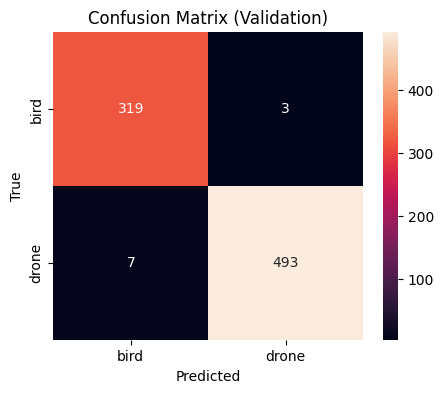

In [21]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        out = model(x)
        preds = out.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["bird", "drone"],
            yticklabels=["bird", "drone"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (Validation)")
plt.show()


In [22]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, 2)
model.fc.requires_grad_(True)
model = model.to(device)


In [23]:
criterion = nn.CrossEntropyLoss(weight=weights)
optimizer = torch.optim.Adam(model.fc.parameters(), lr=1e-4)


In [24]:
EPOCHS = 5
best_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for x, y in train_loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # validation
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            preds = out.argmax(1)
            correct += (preds == y).sum().item()
            total += y.size(0)

    val_acc = correct / total
    best_acc = max(best_acc, val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | Val Acc: {val_acc:.4f}")

print("Best Val Accuracy (Frozen):", best_acc)


Epoch 1/5 | Val Acc: 0.8382
Epoch 2/5 | Val Acc: 0.9148
Epoch 3/5 | Val Acc: 0.9343
Epoch 4/5 | Val Acc: 0.9416
Epoch 5/5 | Val Acc: 0.9440
Best Val Accuracy (Frozen): 0.9440389294403893
